# Guardian — Temporal Action Model: Dataset Build + Training (UCF-Crime)

This notebook is **self-contained**: copy the whole `temporal_training/` folder (this
notebook + `dataset_builder.py` + `model.py`) to the remote GPU server and run top to bottom.
Nothing here modifies `backend/`, `scripts/`, or `trained_model/` — the YOLO detector and its
weights are reused as-is and never touched; all new artifacts land under this same folder
(`temporal_training/sequences/`, `temporal_training/weights/`, `temporal_training/figures/`).

**Phases covered**
1. Download UCF-Crime, run the existing detector + tracker + 12D feature extractor over it
   (`dataset_builder.py`) to build a labeled sequence dataset.
2. Load those sequences into train/val/test splits.
3. Train a lightweight 1D-CNN temporal classifier (see the design-decision cell for why CNN,
   not the GRU already wired into production).
4. Evaluate: learning curves, confusion matrix, precision/recall/F1, accuracy, ROC/PR curves.
5. Export production-ready weights + run inference examples.
6. Document dataset stats, class balance, training config, final metrics, recommendations.


In [1]:
# One-time environment setup on the remote server. temporal_training/ is fully
# self-contained (detection.py has its own copies of the detector/tracker/feature-extractor
# code -- no backend/ package needed here); numpy/opencv/onnxruntime/supervision must still
# be installed for those, alongside the training-only deps below. `requests` is used to
# download the official UCF-Crime release directly (no kagglehub/Kaggle account needed).
#
# Install everything else first -- `supervision` pulls in plain `opencv-python` (the GUI
# build) as its own dependency regardless of what we ask for, so if opencv-headless were
# installed in the same command it can get silently overwritten by that transitive pull.
!pip install -q torch scikit-learn matplotlib seaborn pandas requests tqdm numpy supervision

# Force onnxruntime-gpu in as its own, LAST-wins install -- plain `onnxruntime` is CPU-only
# and silently makes every detector call orders of magnitude slower. Pinned to 1.22.0
# (CUDA 12-linked) rather than latest: as of onnxruntime 1.27 the default wheel links against
# CUDA 13, which most containers don't have the userspace runtime libs for yet even if
# nvidia-smi reports driver support up to CUDA 13 -- see fix_onnxruntime_gpu.sh if you hit
# "libcudart.so.13: cannot open shared object file". Run check_gpu.py after this to confirm
# CUDAExecutionProvider actually loads.
!pip uninstall -y -q onnxruntime onnxruntime-gpu
!pip install -q --force-reinstall --no-deps onnxruntime-gpu==1.22.0 nvidia-cuda-runtime-cu12 nvidia-cublas-cu12 nvidia-cudnn-cu12

# Now force opencv-python-headless in as the LAST, winning install. The GUI `opencv-python`
# build links against libGL/libxcb etc., which most training containers/servers don't have
# installed (and don't need -- nothing here calls cv2.imshow or any other GUI function).
!pip uninstall -y -q opencv-python opencv-python-headless
!pip install -q --force-reinstall --no-deps opencv-python-headless
print("If cv2 was already imported earlier in this kernel session, restart the kernel now "
      "(Kernel -> Restart) before running the next cell, so the headless build is picked up.")



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
If cv2 was already imported earlier in this kernel session, restart the kernel now (Kernel -> Restart) before running the next cell, so the headless build is picked up.


## Setup

In [2]:
import sys
from pathlib import Path

# Run this notebook from inside temporal_training/ (Jupyter's default cwd is wherever the
# .ipynb file lives). This folder has zero dependency on backend/ -- only trained_model/
# (the detector's .onnx weights) needs to sit alongside it as a sibling directory.
TEMPORAL_DIR = Path.cwd()
assert (TEMPORAL_DIR / "dataset_builder.py").exists(), (
    f"Expected to run from temporal_training/, but dataset_builder.py isn't in {TEMPORAL_DIR}. "
    "cd into that folder (or %cd there) before running this cell."
)
SEQUENCES_DIR = TEMPORAL_DIR / "sequences"
WEIGHTS_DIR = TEMPORAL_DIR / "weights"
FIGURES_DIR = TEMPORAL_DIR / "figures"
for d in (SEQUENCES_DIR, WEIGHTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(TEMPORAL_DIR))  # dataset_builder.py / detection.py / model.py (all local)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from detection import ACTION_CLASSES, MODEL_PATH, PERSON_MODEL_PATH  # {0: Normal, 1: Shooting, 2: Violence}
import dataset_builder
from model import TemporalCNNClassifier, NumPyCNNClassifier, export_to_numpy_weights_cnn

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Temporal dir:      {TEMPORAL_DIR}")
print(f"Detector weights:  {MODEL_PATH} (exists={MODEL_PATH.exists()})")
print(f"Person detector:   {PERSON_MODEL_PATH} (exists={PERSON_MODEL_PATH.exists()})")
print(f"Sequences dir:     {SEQUENCES_DIR}")
print(f"Weights dir:       {WEIGHTS_DIR}")
print(f"Device:            {DEVICE}")
print(f"Action classes:    {ACTION_CLASSES}")


Temporal dir:      /tf/temporal_training
Detector weights:  /tf/trained_model/guardian_backend_model.onnx (exists=True)
Person detector:   /tf/trained_model/yolov8s_person.onnx (exists=True)
Sequences dir:     /tf/temporal_training/sequences
Weights dir:       /tf/temporal_training/weights
Device:            cuda
Action classes:    {0: 'Normal', 1: 'Shooting', 2: 'Violence'}


## Phase 1+2 — Dataset Acquisition & Feature-Sequence Extraction

UCF-Crime is mapped directly onto Guardian's 3 action classes (its 13 anomaly categories
cover Abuse, Arrest, Arson, Assault, Burglary, Explosion, Fighting, RoadAccidents, Robbery,
Shooting, Shoplifting, Stealing, Vandalism, plus Normal):

| UCF-Crime category | Guardian class |
|---|---|
| Normal (any "Normal*" variant) | Normal |
| Shooting | Shooting |
| Fighting, Assault | Violence |
| everything else (Abuse, Arrest, Arson, Burglary, Explosion, RoadAccidents, Robbery, Shoplifting, Stealing, Vandalism) | *skipped — out of scope* |

(A fourth class, `Stabbing`, was dropped from Guardian's action taxonomy entirely — UCF-Crime
has no matching category and no other real data source is planned for it, so it would only
ever have shipped untrained. Removed from `ACTION_CLASSES`/`GUARDIAN_CLASSES` here and in
`detection.py`/`dataset_builder.py`, from the production `NumPyGRUClassifier` in
`backend/bl/detection/temporal_action.py`, and from the frontend admin dashboard.)

All of the actual detect→track→extract work reuses Guardian's existing detection stack
(YOLO ONNX detector, ByteTrack wrapper, `TemporalFeatureExtractor`) via the self-contained
copies in `detection.py`, driven by `dataset_builder.py` — see those files for the full
logic. This notebook just drives it.

**Two detectors are merged per frame**: the primary `guardian_backend_model.onnx`
(Gun/Knife/Suspect) plus a generic COCO-pretrained `yolov8s_person.onnx` — its "person"
class is remapped to Guardian's Suspect class and merged in (`detection.merge_person_detections`,
de-duplicated via NMS against the primary detector's own Suspect boxes). The primary detector's
own "Suspect" class may rarely fire on UCF-Crime footage (different camera domain than
whatever it was trained on); the generic person detector is a much stronger, general-purpose
signal for "is there a person in frame" on arbitrary surveillance video, so tracks/sequences
end up anchored on person detections from either source. Weapon detections are untouched —
the person detector never produces those. On any frame where the primary detector already
found a Suspect, the person detector isn't called at all -- no need for a second forward pass
once a person is already confirmed.

**Performance notes** (this loop runs two detectors over every sampled frame across many
videos, so it's worth keeping cheap):
- `detection.py`'s `_postprocess` is fully vectorized (numpy array ops, not a per-candidate
  Python loop) -- with an 80-class COCO output (8400 candidate boxes for the person
  detector), the naive per-row version spent more time in interpreted Python than the actual
  ONNX forward pass took.
- `dataset_builder.iter_frames_adaptive` (below) skips frames aggressively while nothing's
  been detected recently and only samples densely once something is. See the speed-dial cell
  for `FRAME_STEP`/`IDLE_FRAME_STEP`.
- None of this compensates for ONNX Runtime silently running on CPU -- see recommendation #6
  in Phase 6 if a build is still much slower than expected.


In [3]:
# Set to True to force a full Phase 1+2 re-run (re-download + re-detect everything) even if
# sequences/ already has data from a previous run -- e.g. to add more videos or rebuild from
# scratch after changing MAX_VIDEOS_PER_CLASS/FRAME_STEP/MAX_FRAMES_PER_VIDEO below.
REBUILD_DATASET = False

existing_sequence_counts = {
    cls: len(list((SEQUENCES_DIR / cls).glob("*.npy"))) for cls in dataset_builder.GUARDIAN_CLASSES
}
SKIP_DATASET_BUILD = (not REBUILD_DATASET) and sum(existing_sequence_counts.values()) > 0

if SKIP_DATASET_BUILD:
    print(f"Found existing sequences on disk, skipping the (multi-hour/day) Phase 1+2 rebuild: {existing_sequence_counts}")
    print("Set REBUILD_DATASET = True above to force a full re-run instead.")
else:
    print("No existing sequences found (or REBUILD_DATASET=True) -- Phase 1+2 will run below.")


Found existing sequences on disk, skipping the (multi-hour/day) Phase 1+2 rebuild: {'Normal': 9075, 'Shooting': 3881, 'Violence': 16097}
Set REBUILD_DATASET = True above to force a full re-run instead.


In [4]:
# Downloads only the UCF-Crime zips that can contain Shooting/Fighting/Assault/Normal (see
# dataset_builder.UCF_CRIME_FILES for why these specific files) from a HuggingFace mirror of
# the official release, NOT a third-party Kaggle mirror -- several Kaggle uploads claim to be
# "the full UCF-Crime dataset" but silently omit whole categories (mission-ai/crimeucfdataset,
# tried first, turned out to have no Shooting videos at all). This is ~26GB total instead of
# the full corpus's 100GB+. dataset_builder.py's category discovery is recursive/substring-
# based, so it doesn't care which of the 4 Anomaly-Videos parts each category landed in.
UCF_CRIME_ROOT = None
if not SKIP_DATASET_BUILD:
    try:
        UCF_CRIME_ROOT = dataset_builder.download_official_ucf_crime(TEMPORAL_DIR / "raw_ucf_crime")
        print(f"UCF-Crime downloaded to: {UCF_CRIME_ROOT}")
    except Exception as e:
        # Fall back to a manually-provided local path if the download fails/is unavailable here
        # (e.g. no outbound internet from this container) -- place the dataset there yourself.
        UCF_CRIME_ROOT = TEMPORAL_DIR / "raw_ucf_crime" / "UCF_Crimes"
        print(f"Official download failed ({e}); falling back to local path: {UCF_CRIME_ROOT}")
else:
    print("Skipping download (SKIP_DATASET_BUILD=True) -- reusing sequences already on disk.")


Skipping download (SKIP_DATASET_BUILD=True) -- reusing sequences already on disk.


In [5]:
# Speed/size dials -- the full UCF-Crime Normal/Shooting/Fighting/Assault subset can still
# be tens of GB and take *days* to run frame-by-frame through two detectors. Tune these down
# further (or set to None/1 to disable) if you want more coverage and can afford the runtime;
# tune them up (smaller MAX_FRAMES_PER_VIDEO, bigger IDLE_FRAME_STEP) if it's still too slow.
MAX_VIDEOS_PER_CLASS = 300  # random seeded sample per class, not just the first N found
FRAME_STEP = 1              # "active" step: full resolution once something's being tracked
IDLE_FRAME_STEP = 8         # "idle" step: skip aggressively while nothing's been detected --
                            # long boring stretches (esp. Normal-category videos) burn most of
                            # the runtime otherwise; see iter_frames_adaptive in dataset_builder.py
MAX_FRAMES_PER_VIDEO = 1800 # bounds very long Normal-category videos in particular

# Phase 1+2 driver: detect (both models) -> track -> extract 12D feature sequences -> save
# under SEQUENCES_DIR/<Class>/*.npy. use_person_detector=True merges in yolov8s_person.onnx's
# "person" boxes as extra Suspect tracks (falls back to the primary detector alone, with a
# logged warning, if that weights file isn't present; also skipped outright on any frame
# where the primary detector already found a Suspect). Safe to re-run: dataset_builder writes
# new files, doesn't delete/overwrite existing ones (rerun with a clean SEQUENCES_DIR to
# rebuild from scratch).
#
# Note on frame skipping: sequences sampled during an idle->active transition can span more
# real time per 30-step window than production inference does (which runs on every live
# camera frame) -- the dx/dy velocity features will be less uniform across that window. A
# reasonable, documented trade-off for a practical training run; revisit if the trained
# model's confidence calibration looks off vs. live footage (see Phase 6 recommendations).
if SKIP_DATASET_BUILD:
    # Cheap reconstruction from disk -- videos_per_class/skipped_categories aren't recoverable
    # without re-running detection, so they're left empty; only sequences_per_class (what the
    # rest of the notebook actually needs) is populated.
    build_stats = {
        "videos_per_class": {},
        "sequences_per_class": existing_sequence_counts,
        "skipped_categories": {},
    }
else:
    build_stats = dataset_builder.build_dataset(
        data_root=UCF_CRIME_ROOT,
        out_dir=SEQUENCES_DIR,
        stride=dataset_builder.DEFAULT_STRIDE,
        use_person_detector=True,
        max_videos_per_class=MAX_VIDEOS_PER_CLASS,
        frame_step=FRAME_STEP,
        idle_frame_step=IDLE_FRAME_STEP,
        max_frames_per_video=MAX_FRAMES_PER_VIDEO,
    )
build_stats


{'videos_per_class': {},
 'sequences_per_class': {'Normal': 9075, 'Shooting': 3881, 'Violence': 16097},
 'skipped_categories': {}}

## Design Decision — Why a 1D CNN (not the GRU already wired into production)

`backend/bl/detection/pipeline.py` currently calls a GRU classifier
(`NumPyGRUClassifier` in `backend/bl/detection/temporal_action.py`) — but it has never been
trained (no `trained_model/temporal_action_weights.npz` exists; production runs on
deterministic random weights today).

Per the task brief's own preference order (1D CNN first, GRU only "if it has a strong
reason") and explicit direction to prefer an easier-to-train model even if it requires
changes, this notebook trains a **1D CNN** (`model.TemporalCNNClassifier`) instead:

- **Easier to train**: fully parallel across the 30-step sequence (no backprop-through-time),
  a much simpler loss landscape than a recurrent model, especially valuable given UCF-Crime's
  sequence yield for this task is small/uncertain (see Phase 6 dataset stats).
- **Fewer ways to get the NumPy port wrong**: a hand-written conv1d + ReLU + pool forward pass
  (`model.NumPyCNNClassifier`) has no gate equations to subtly mis-transcribe, unlike a GRU's
  reset/update/new gates.
- **Comparable size**: 32 hidden channels, same 12-dim input / 3-class output contract as the
  existing GRU.

This intentionally does **not** touch `backend/bl/detection/temporal_action.py` or
`pipeline.py` — those keep running the (untrained) GRU. `model.py` ships its own
zero-dependency NumPy mirror for this notebook's own validation. **Promoting this CNN to
production is a separate, reviewed follow-up**: add `NumPyCNNClassifier` to
`backend/bl/detection/temporal_action.py` and point `pipeline.py`'s `_action_classifier` at
it — not done automatically here, since it would change live inference behavior as a side
effect of a training notebook.


## Phase 3 — Dataset loading & train/val/test split

In [6]:
CLASS_TO_INDEX = {name: idx for idx, name in ACTION_CLASSES.items()}


def collect_file_label_pairs(sequences_dir: Path) -> list[tuple[Path, int]]:
    pairs = []
    for cls_name, idx in CLASS_TO_INDEX.items():
        for p in sorted((sequences_dir / cls_name).glob("*.npy")):
            pairs.append((p, idx))
    return pairs


def stratified_split(pairs, ratios=(0.70, 0.15, 0.15), seed=SEED):
    rng = np.random.default_rng(seed)
    by_label: dict[int, list[Path]] = {}
    for path, label in pairs:
        by_label.setdefault(label, []).append(path)

    train, val, test = [], [], []
    for label, paths in by_label.items():
        paths = list(paths)
        rng.shuffle(paths)
        n = len(paths)
        n_train = int(n * ratios[0])
        n_val = int(n * ratios[1])
        train += [(p, label) for p in paths[:n_train]]
        val += [(p, label) for p in paths[n_train:n_train + n_val]]
        test += [(p, label) for p in paths[n_train + n_val:]]
    return train, val, test


class NpySequenceDataset(Dataset):
    """Loads (30, 12) feature sequences from temporal_training/sequences/<Class>/*.npy."""

    def __init__(self, file_label_pairs: list[tuple[Path, int]]):
        self.file_label_pairs = file_label_pairs

    def __len__(self) -> int:
        return len(self.file_label_pairs)

    def __getitem__(self, idx: int):
        path, label = self.file_label_pairs[idx]
        seq = np.load(path).astype(np.float32)
        return torch.from_numpy(seq), label


all_pairs = collect_file_label_pairs(SEQUENCES_DIR)
assert len(all_pairs) > 0, (
    f"No sequences found under {SEQUENCES_DIR} -- did the Phase 1+2 dataset_builder cell run "
    "successfully? (check that UCF_CRIME_ROOT actually contains Shooting/Fighting/Assault/Normal "
    "folders with videos)"
)

train_pairs, val_pairs, test_pairs = stratified_split(all_pairs)
train_ds, val_ds, test_ds = (NpySequenceDataset(p) for p in (train_pairs, val_pairs, test_pairs))

print(f"Total sequences: {len(all_pairs)}")
print(f"Train/Val/Test:  {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")


Total sequences: 29053
Train/Val/Test:  20335/4357/4361


## Phase 4 — Training (early stopping + best-checkpoint)

In [7]:
EPOCHS = 300
PATIENCE = 8
LR = 1e-3
BATCH_SIZE = 32
BEST_CKPT = WEIGHTS_DIR / "temporal_action_best.pt"

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = TemporalCNNClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_loss, train_acc = running_loss / total, correct / total

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    val_loss, val_acc = running_loss / total, correct / total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:3d}/{EPOCHS}: train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_CKPT)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
            break

model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
print(f"\nLoaded best checkpoint (val_loss={best_val_loss:.4f}) from {BEST_CKPT}")


Epoch   1/300: train_loss=0.9192 train_acc=0.561 val_loss=0.8953 val_acc=0.574
Epoch   2/300: train_loss=0.8752 train_acc=0.590 val_loss=0.8607 val_acc=0.609
Epoch   3/300: train_loss=0.8556 train_acc=0.603 val_loss=0.8704 val_acc=0.586
Epoch   4/300: train_loss=0.8408 train_acc=0.613 val_loss=0.8357 val_acc=0.632
Epoch   5/300: train_loss=0.8239 train_acc=0.623 val_loss=0.8142 val_acc=0.633
Epoch   6/300: train_loss=0.8079 train_acc=0.635 val_loss=0.8102 val_acc=0.642
Epoch   7/300: train_loss=0.7989 train_acc=0.639 val_loss=0.7971 val_acc=0.643
Epoch   8/300: train_loss=0.7892 train_acc=0.648 val_loss=0.7965 val_acc=0.643
Epoch   9/300: train_loss=0.7813 train_acc=0.648 val_loss=0.7819 val_acc=0.654
Epoch  10/300: train_loss=0.7741 train_acc=0.657 val_loss=0.7867 val_acc=0.638
Epoch  11/300: train_loss=0.7675 train_acc=0.662 val_loss=0.7713 val_acc=0.656
Epoch  12/300: train_loss=0.7615 train_acc=0.661 val_loss=0.7850 val_acc=0.638
Epoch  13/300: train_loss=0.7515 train_acc=0.670 val

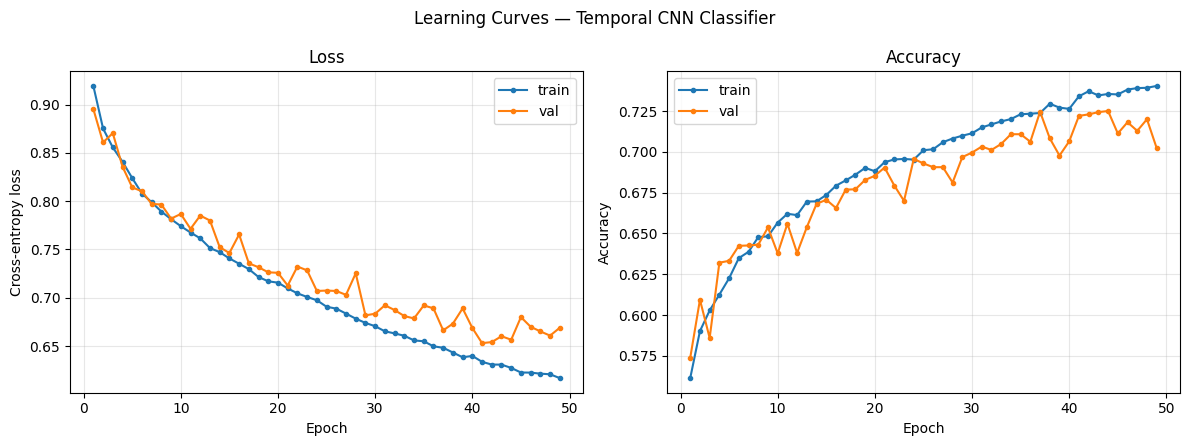

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="train", marker="o", markersize=3)
axes[0].plot(epochs_range, history["val_loss"], label="val", marker="o", markersize=3)
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="train", marker="o", markersize=3)
axes[1].plot(epochs_range, history["val_acc"], label="val", marker="o", markersize=3)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle("Learning Curves — Temporal CNN Classifier")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "learning_curves.png", dpi=150)
plt.show()


## Phase 4 — Test-set Evaluation

In [9]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        all_logits.append(logits.cpu().numpy())
        all_labels.append(yb.numpy())

all_logits = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels)
all_probs = torch.softmax(torch.from_numpy(all_logits), dim=1).numpy()
all_preds = all_logits.argmax(axis=1)

class_names_ordered = [ACTION_CLASSES[i] for i in range(len(ACTION_CLASSES))]
test_accuracy = float((all_preds == all_labels).mean())
print(f"Test accuracy: {test_accuracy:.4f}  (n={len(all_labels)})")


Test accuracy: 0.7368  (n=4361)


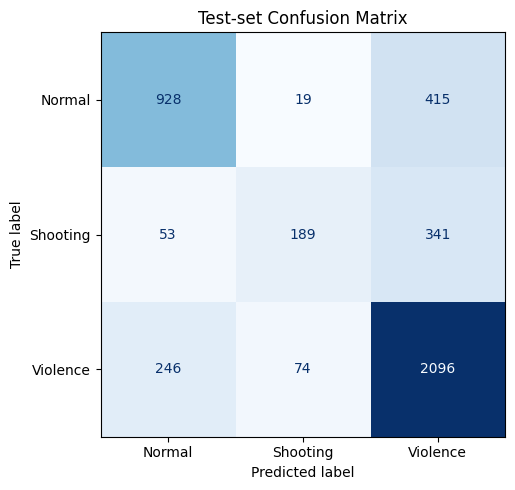

In [10]:
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(ACTION_CLASSES))))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names_ordered).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Test-set Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
plt.show()


In [11]:
report_dict = classification_report(
    all_labels, all_preds,
    labels=list(range(len(ACTION_CLASSES))), target_names=class_names_ordered,
    zero_division=0, output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df


,precision,recall,f1-score,support
Normal,0.756316,0.681351,0.716879,1362.000000
Shooting,0.670213,0.324185,0.436994,583.000000
Violence,0.734923,0.867550,0.795748,2416.000000
accuracy,0.736758,0.736758,0.736758,0.736758
macro avg,0.720484,0.624362,0.649874,4361.000000
weighted avg,0.732954,0.736758,0.723156,4361.000000


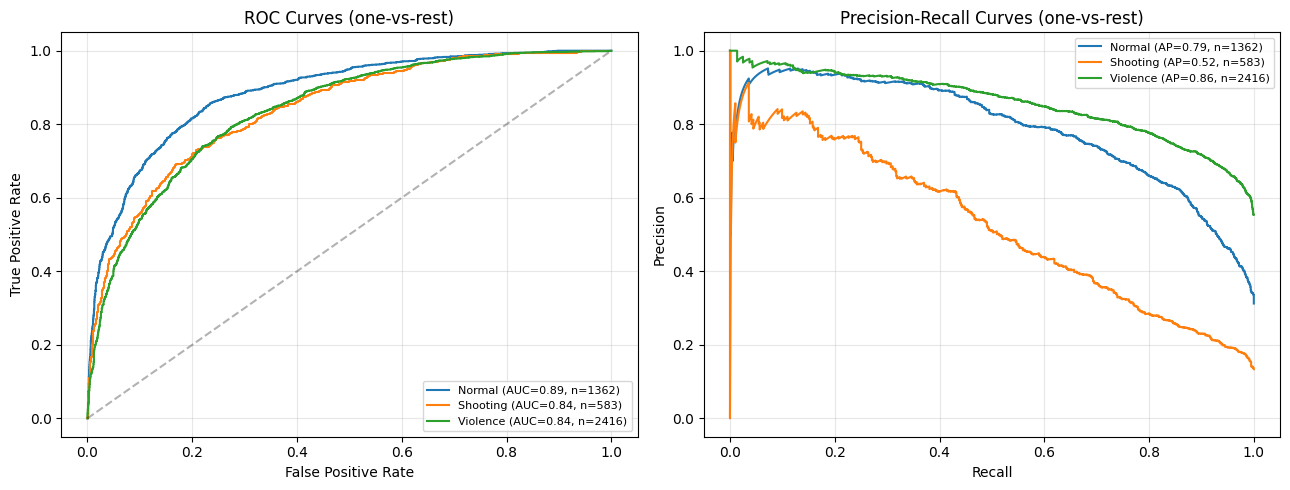

In [12]:
y_bin = label_binarize(all_labels, classes=list(range(len(ACTION_CLASSES))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, cls_name in enumerate(class_names_ordered):
    support = int(y_bin[:, i].sum())
    if support == 0:
        print(f"Skipping ROC/PR curve for '{cls_name}': 0 positive samples in the test set.")
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    axes[0].plot(fpr, tpr, label=f"{cls_name} (AUC={auc(fpr, tpr):.2f}, n={support})")

    prec, rec, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    ap = average_precision_score(y_bin[:, i], all_probs[:, i])
    axes[1].plot(rec, prec, label=f"{cls_name} (AP={ap:.2f}, n={support})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (one-vs-rest)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (one-vs-rest)"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_pr_curves.png", dpi=150)
plt.show()


## Phase 5 — Export production-ready weights

In [13]:
EXPORT_PATH = WEIGHTS_DIR / "temporal_action_weights.npz"
export_to_numpy_weights_cnn(model, EXPORT_PATH)

print(f"Exported CNN weights (NumPy-loadable) to: {EXPORT_PATH}")
print(f"Best PyTorch checkpoint (.pt):           {BEST_CKPT}")
print(
    "\nNOTE: this npz uses a *different* key contract (conv1_w/conv1_b/conv2_w/conv2_b/fc_w/fc_b) "
    "than trained_model/temporal_action_weights.npz, which backend/bl/detection/temporal_action.py's "
    "NumPyGRUClassifier expects (w_ih/w_hh/b_ih/b_hh/w_fc/b_fc). Promoting this model to production "
    "means adding a NumPyCNNClassifier to that file and pointing pipeline.py's classifier at it -- "
    "a deliberate, reviewed follow-up, not an automatic file copy."
)


Exported CNN weights (NumPy-loadable) to: /tf/temporal_training/weights/temporal_action_weights.npz
Best PyTorch checkpoint (.pt):           /tf/temporal_training/weights/temporal_action_best.pt

NOTE: this npz uses a *different* key contract (conv1_w/conv1_b/conv2_w/conv2_b/fc_w/fc_b) than trained_model/temporal_action_weights.npz, which backend/bl/detection/temporal_action.py's NumPyGRUClassifier expects (w_ih/w_hh/b_ih/b_hh/w_fc/b_fc). Promoting this model to production means adding a NumPyCNNClassifier to that file and pointing pipeline.py's classifier at it -- a deliberate, reviewed follow-up, not an automatic file copy.


## Phase 5 — Inference Examples

In [14]:
np_clf = NumPyCNNClassifier(weights_path=EXPORT_PATH)

rng = np.random.default_rng(0)
sample_indices = rng.choice(len(test_ds), size=min(5, len(test_ds)), replace=False)

max_abs_diff = 0.0
for idx in sample_indices:
    seq_tensor, label = test_ds[int(idx)]
    seq_np = seq_tensor.numpy()

    with torch.no_grad():
        torch_probs = torch.softmax(model(seq_tensor.unsqueeze(0).to(DEVICE)), dim=1).cpu().numpy()[0]
    np_probs = np_clf.forward(seq_np)
    diff = float(np.max(np.abs(torch_probs - np_probs)))
    max_abs_diff = max(max_abs_diff, diff)

    pred_idx, pred_conf = np_clf.predict(seq_np)
    print(f"true={ACTION_CLASSES[label]:10s} numpy_pred={ACTION_CLASSES[pred_idx]:10s} "
          f"conf={pred_conf:.3f}  torch_vs_numpy_max_abs_diff={diff:.2e}")

# One runnable check for the hand-ported NumPy conv1d forward pass: it must reproduce the
# trained PyTorch model's output on real weights, not just look reasonable in isolation.
assert max_abs_diff < 1e-4, "NumPy mirror diverges from the trained PyTorch model -- check model.conv1d_same"
print(f"\nOK: NumPy inference mirror matches the trained PyTorch model (max abs diff={max_abs_diff:.2e}).")


true=Violence   numpy_pred=Normal     conf=0.519  torch_vs_numpy_max_abs_diff=2.38e-07
true=Violence   numpy_pred=Violence   conf=0.896  torch_vs_numpy_max_abs_diff=5.96e-08
true=Normal     numpy_pred=Violence   conf=0.463  torch_vs_numpy_max_abs_diff=1.19e-07
true=Normal     numpy_pred=Normal     conf=0.706  torch_vs_numpy_max_abs_diff=1.19e-07
true=Violence   numpy_pred=Violence   conf=0.598  torch_vs_numpy_max_abs_diff=1.79e-07

OK: NumPy inference mirror matches the trained PyTorch model (max abs diff=2.38e-07).


## Phase 6 — Documentation

### Dataset statistics & class balance

In [15]:
stats_df = pd.DataFrame({
    "videos_processed": build_stats["videos_per_class"],
    "sequences_saved": build_stats["sequences_per_class"],
}).fillna(0).astype(int)
print("Skipped (out-of-scope) UCF-Crime categories and their unit counts:")
print(build_stats["skipped_categories"])
stats_df


Skipped (out-of-scope) UCF-Crime categories and their unit counts:
{}


,videos_processed,sequences_saved
Normal,0,9075
Shooting,0,3881
Violence,0,16097


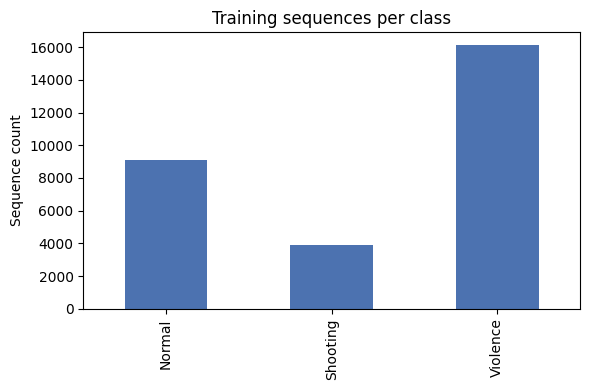

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
stats_df["sequences_saved"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Training sequences per class")
ax.set_ylabel("Sequence count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=150)
plt.show()


### Training configuration & final metrics

In [17]:
config_summary = {
    "architecture": "TemporalCNNClassifier (2x Conv1d(k=5) + global-avg-pool + FC)",
    "input_shape": "(30 timesteps, 12 features)",
    "hidden_channels": 32,
    "num_classes": len(ACTION_CLASSES),
    "epochs_configured": EPOCHS,
    "epochs_run": len(history["train_loss"]),
    "early_stopping_patience": PATIENCE,
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "train_val_test_split": "70/15/15 (stratified per class)",
    "best_val_loss": round(best_val_loss, 4),
    "test_accuracy": round(test_accuracy, 4),
}
pd.Series(config_summary).to_frame("value")


,value
architecture,TemporalCNNClassifier (2x Conv1d(k=5) + global...
input_shape,"(30 timesteps, 12 features)"
hidden_channels,32
num_classes,3
epochs_configured,300
epochs_run,49
early_stopping_patience,8
learning_rate,0.001
batch_size,32
optimizer,Adam


In [18]:
report_df[["precision", "recall", "f1-score", "support"]].round(3)


,precision,recall,f1-score,support
Normal,0.756,0.681,0.717,1362.000
Shooting,0.670,0.324,0.437,583.000
Violence,0.735,0.868,0.796,2416.000
accuracy,0.737,0.737,0.737,0.737
macro avg,0.720,0.624,0.650,4361.000
weighted avg,0.733,0.737,0.723,4361.000


### Recommendations

1. **Domain shift.** UCF-Crime surveillance footage differs in camera angle/quality from
   whatever Guardian's own YOLO detector was trained/validated on. If the dataset-statistics
   table above shows very few sequences relative to videos processed, the detector likely
   rarely fires a "Suspect" track on this footage — spot-check a few sample frames/videos
   before trusting the class-balance numbers.
2. **Class imbalance / sparsity.** If per-class sequence counts (see bar chart above) are
   heavily skewed, consider lowering `dataset_builder.DEFAULT_STRIDE` (denser sampling) for
   under-represented classes, or motion-based sampling instead of fixed-stride.
3. **Promotion to production is a separate step.** This notebook intentionally does not touch
   `backend/bl/detection/temporal_action.py` or `pipeline.py`. Adopting this CNN in production
   means adding `NumPyCNNClassifier` there and pointing `pipeline.py`'s `_action_classifier`
   at it, then re-validating the `>= 0.70` confidence gate in `pipeline.py` against *this*
   model's own ROC/PR curves (a threshold tuned for the old, untrained GRU has no particular
   relevance to this model).
4. **Re-run on more data if the dataset is small.** UCF-Crime's Shooting/Fighting/Assault
   categories are a small fraction of the full corpus; if test-set support per class (see the
   precision/recall/F1 table above) is in the low tens, treat these metrics as directional,
   not final, and prioritize collecting more labeled sequences before shipping.
5. **Idle/active frame stepping changes the time span a 30-step window covers.** The Phase
   1+2 cell samples densely (`FRAME_STEP`) only once something's being tracked, and skips
   aggressively (`IDLE_FRAME_STEP`) otherwise -- see `dataset_builder.iter_frames_adaptive`.
   Production inference runs on every live camera frame, so a sequence sampled right after an
   idle->active transition sees less uniform per-step displacement (dims 4-7) than live
   inference will. If confidence scores look miscalibrated against real footage, retrain with
   `IDLE_FRAME_STEP = FRAME_STEP` (i.e. disable adaptive skipping) on a smaller
   `MAX_VIDEOS_PER_CLASS` instead.
6. **If Phase 1+2 is still slow even with these dials**, run `check_gpu.py` (same folder) --
   it confirms whether ONNX Runtime is actually using CUDA (not just that `onnxruntime-gpu`
   is installed) and times real inference calls. If `CUDAExecutionProvider` isn't active,
   that dwarfs every other speed lever here.
